# Predicting protein-pocket hydration sites using Fire Opal
**Optimize water placement in protein binding sites using Fire Opal**

Predicting the location of water molecules in protein binding pockets is a critical task in Computer-Aided Drug Discovery (CADD), directly influencing drug lead optimization and molecular docking calculations. In a recent paper, [D. Loco et al. (2025)](https://arxiv.org/abs/2512.08390) show how to formulate the water placement problem as a combinatorial optimization problem, making it a natural candidate for a quantum approach. Using [Q-CTRL's Fire Opal optimization solver](https://docs.q-ctrl.com/fire-opal/execute/run-algorithms/solve-optimization-problems), the authors achieved:

- Successful QUBO optimization on IBM Heron devices with up to 123 qubits
- Optimal solution identification across all 11 test instances, outperforming greedy local solvers
- Performance on par with or superior to classical hydration-site prediction methods
- Significant improvement on Heron r3 vs. r2 hardware, highlighting the path to quantum advantage

## 1. Introduction

### 1.1 The Water Placement Problem in Drug Discovery

Water molecules play a fundamental role in protein–ligand binding. As a primary component of biological environments, water influences the structural stability of proteins and the interactions between proteins and drug candidates (ligands). Interfacial waters can mediate binding, acting as bridges between the protein and the ligand, making accurate prediction of their positions essential for estimating drug binding affinity and optimizing drug candidates.

However, predicting the configuration of water molecules in protein binding pockets presents a computational challenge. The high dimensionality of the problem and the vast conformational space that must be sampled make this task expensive even for state-of-the-art classical methods such as molecular dynamics and Monte Carlo simulations, which rely heavily on GPU acceleration and massive parallelism.

### 1.2 QUBO Formulation for Hydration-Site Prediction

The approach presented here maps the water placement problem onto a Quadratic Unconstrained Binary Optimization (QUBO) formulation. Starting from a 3D Reference Interaction Site Model (3D-RISM) continuous water density $g(\mathbf{r})$, the method approximates this density as a Gaussian Mixture Model (GMM). Each Gaussian component represents a potential hydration site, and the problem becomes selecting the optimal subset of sites that best fits the underlying density.

A set of $N$ binary variables $\mathbf{x} = (x_1, x_2, \ldots, x_N)$ is introduced, where $x_i = 1$ indicates a water molecule is placed at site $i$ and $x_i = 0$ indicates it is not. The objective is to minimize the $L^2$-norm between the 3D-RISM density and the GMM approximation:

$$I^2 := \int_C \left( g(\mathbf{r}) - \sum_{i=1}^{N} \mathcal{G}(\mathbf{q}_i, \sigma^2)(\mathbf{r})\, x_i \right)^2 d\mathbf{r},$$

where $\mathcal{G}(\mathbf{q}_i, \sigma^2)$ is an isotropic Gaussian centered at grid point $\mathbf{q}_i$ with variance $\sigma^2$. Expanding the square yields a standard QUBO cost function:

$$\min_{\mathbf{x} \in \{0,1\}^N} C(\mathbf{x}) = \sum_{i=1}^{N} Q_{ii}\, x_i + 2 \sum_{i<j} Q_{ij}\, x_i x_j.$$

The QUBO matrix $Q \in \mathbb{R}^{N \times N}$ encodes the full energy landscape:

- **Linear terms** $Q_{ii}$: self-energy of placing a water molecule at site $i$, reflecting its interaction with the protein environment. Negative values indicate energetically favorable sites
- **Quadratic terms** $Q_{ij}$: pairwise interaction energy between sites $i$ and $j$. Large positive penalties enforce minimum distance constraints between water molecules

## 2. The Computation Pipeline

Figure 1 shows the end-to-end workflow for the QUBO-based hydration-site prediction. Starting from a protein 3D structure, a 3D-RISM continuous water density $g(\mathbf{r})$ is computed using the AmberTools package. The density is then discretized onto a coarser grid within the binding pocket region, applying a grid spacing $\delta$ and density threshold $\tau_g$ to reduce the problem to a tractable size. The resulting grid defines the binary variables for the QUBO formulation, and the QUBO matrix is computed from the Gaussian overlap integrals. Q-CTRL's Fire Opal optimization solver executes the QUBO on quantum hardware, and the best solution bitstring directly encodes the 3D coordinates of predicted water molecules.

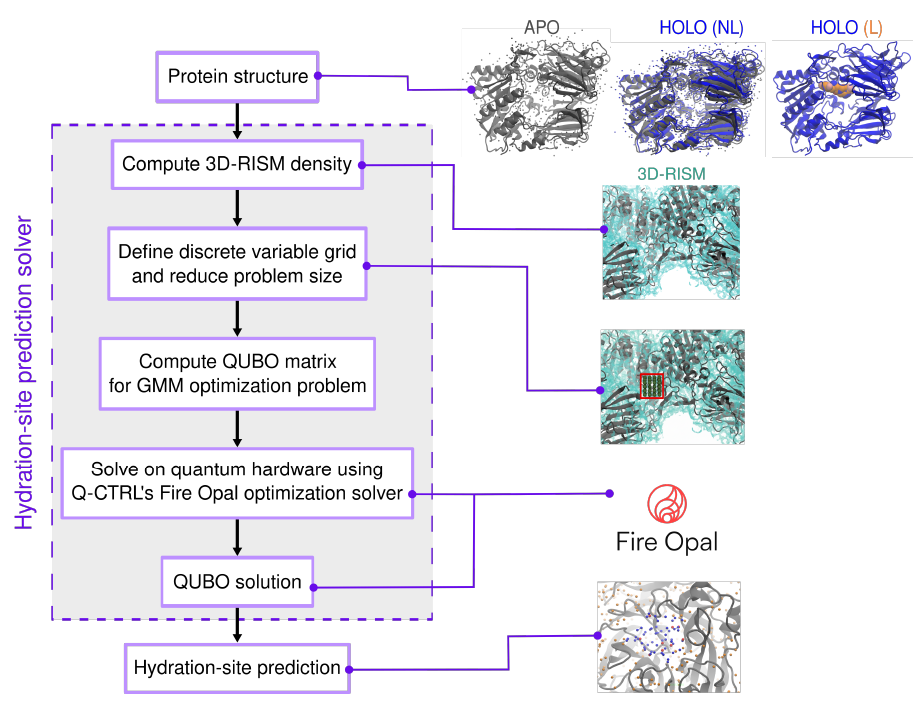
Figure 1: Full-stack workflow for the QUBO-based hydration-site prediction. A 3D-RISM continuous water density within the protein of choice is converted into a binary variable placement grid. The QUBO matrix maps the density information into a combinatorial optimization problem. The QUBO matrix is fed into Q-CTRL's Fire Opal optimization solver, whose output directly reads as 3D coordinates of predicted water molecule sites.

### 2.1 3D-RISM Density Computation

The 3D-RISM theory provides the probability density of solvent molecules around a solute on a set of spatial grid points. High values of $g(\mathbf{r})$ correspond to regions of high solvent concentration relative to bulk, indicating stable water molecule locations due to strong water–protein interactions. The density is computed on a grid with spacing $\delta = 0.5$ Å using the ff14SB Amber force field for the protein and the SPC/E water model for the solvent.

### 2.2 Dimensionality Reduction

The original 3D-RISM grids contain on the order of $10^6$ points, far exceeding both current quantum hardware and practical classical solver capabilities. The problem size is reduced through three steps:

1. Restricting attention to the protein binding pocket (a cubic subdomain of $15$ Å sides)
2. Re-sampling $g(\mathbf{r})$ on a coarser grid with spacing $\delta > 0.5$ Å
3. Removing low-density points below a threshold $\tau_g$

These reductions yield QUBO instances with 41–116 binary variables, each mapping to one qubit on the quantum device.

## 3. Test Systems: Realistic Drug-Protein Complexes

The method was tested on a set of protein structures relevant to health care applications, all associated with FDA-approved drugs. The structures were selected from the Protein Data Bank (PDB) to cover different protein sizes and families.

<center>

| PDB ID | # Crystal Waters | # Residues | MW (kDa) | Resolution (Å) |
|--------|-----------------|------------|----------|----------------|
| 1f9g   | 6               | 25         | 83.7     | 2.0            |
| 1x70   | 16              | 18         | 174.9    | 2.1            |
| 2f9w   | 15              | 10         | 59.9     | 1.9            |
| 3b7e   | 28              | 15         | 86.8     | 1.45           |
| 4h2f   | 13              | 27         | 60.8     | 1.85           |
| 3beq   | 10              | 15         | 87.0     | 1.64           |

</center>

For each protein-ligand complex, two variants were considered: with the ligand included (L) in the 3D-RISM calculation, and without it (NL). PDB ID 3beq is the apo structure of 3b7e, providing an additional test case. The resulting QUBO instances are summarized below:

<center>

| Instance    | # Variables | $\delta$ (Å) | $\tau_g$ | $\sigma^2$ (Å$^2$) | Label |
|-------------|-------------|---------------|----------|---------------------|-------|
| 1f9g (L)    | 98          | 1.05          | 0.17     | 0.8                 | a     |
| 1f9g (NL)   | 91          | 1.05          | 0.17     | 0.8                 | b     |
| 1x70 (L)    | 69          | 0.95          | 0.10     | 0.8                 | c     |
| 1x70 (NL)   | 116         | 0.95          | 0.10     | 0.8                 | d     |
| 2f9w (L)    | 41          | 1.05          | 0.10     | 0.8                 | e     |
| 2f9w (NL)   | 92          | 1.05          | 0.10     | 0.8                 | f     |
| 3b7e (L)    | 71          | 1.15          | 0.10     | 1.0                 | g     |
| 3b7e (NL)   | 90          | 1.15          | 0.10     | 1.0                 | h     |
| 4h2f (L)    | 82          | 0.95          | 0.12     | 0.8                 | i     |
| 4h2f (NL)   | 79          | 0.95          | 0.12     | 0.8                 | l     |
| 3beq (APO)  | 72          | 1.25          | 0.10     | 1.0                 | m     |

</center>

## 4. Fire Opal Optimization Solver

To tackle the hydration-site prediction QUBO problems on IBM quantum devices, Q-CTRL's Fire Opal optimization solver is employed. The solver implements an enhanced variational quantum optimization pipeline built on QAOA principles, with several critical components:

- **Enhanced variational ansatz**: The input QUBO matrix $Q$ defines the cost polynomial $C(\mathbf{x}) = \mathbf{x}^T Q \mathbf{x}$, which is used to set up an ansatz circuit that goes beyond standard QAOA.
- **Efficient parametric pre-compilation**: The ansatz circuit is compiled using an enriched gate set with pre-calibrated, pulse-level instructions to minimize overhead in the hybrid optimization loop.
- **Automated error suppression**: Q-CTRL's performance management pipeline deterministically reduces noise impact without additional sampling overhead.
- **Classical parameter optimization**: Circuit parameters are updated by a classical optimizer configured to maximize quantum resource utilization.
- **Classical postprocessing**: Measured bitstrings are refined via local search to correct uncorrelated bit-flip errors.

This end-to-end pipeline has demonstrated the ability to solve nontrivial binary combinatorial optimization problems.

## 5. Results

### 5.1 Quantum Hardware QUBO Solutions

The QUBO instances from the test set were solved on IBM Heron devices using Q-CTRL's optimization solver. Figure 2 shows the cost distribution for the largest test instance (instance "d", 116 qubits) on `ibm_kingston`, compared to the exact CPLEX solution and classical heuristics. The Q-CTRL solver finds the optimal solution with approximately 9% sampling probability, significantly outperforming simulated annealing (~2%) and a greedy local solver which fails to find the optimum. The Q-CTRL solver identifies the optimal solution across all 11 test instances. Figure 3 shows the success probabilities for the full test set ranging from 41 to 116 qubits.

<center>
    
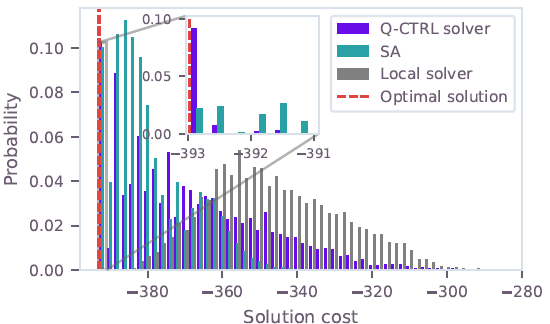

</center>

Figure 2: Cost distributions for the 116-qubit hydration-site prediction QUBO (instance d). The Q-CTRL solver output on `ibm_kingston` (purple) is compared to the CPLEX optimal solution (dashed red), simulated annealing (teal), and a greedy local solver (gray).

<center>
    
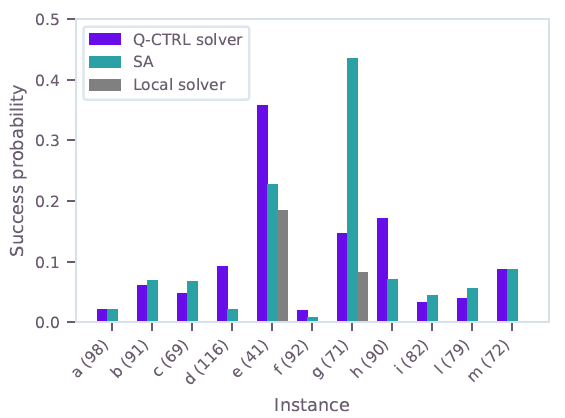

</center>

Figure 3: Probability of sampling the optimal solution for all test-set instances using the Q-CTRL solver on `ibm_kingston` (purple), simulated annealing (teal), and a greedy local solver (gray). Variable counts shown in parentheses. 

### 5.2 Beyond Exact Classical Solvers: 123 Qubits

For the 3b7e-with-ligand structure at a grid spacing of 1.9 Å (123 variables), the exact classical solver CPLEX fails to find the optimal solution within a 3-hour cutoff, with the optimality gap stalling around 40%. The Q-CTRL solver finds a lower-cost solution ($C_{\text{best, Q-CTRL}} = -321.32$) than CPLEX's best feasible solution ($C_{\text{best, CPLEX}} = -319.90$) in only 25 minutes on `ibm_pittsburgh`.

Importantly, the paper notes that both SA and the Q-CTRL solver reach the same best cost on this instance, with SA achieving higher sampling probability — attributed to the quantum resources approaching current device limits in gate fidelities, circuit depth, and $T_1$ times. Nevertheless, both heuristic approaches outperform the exact classical solver, and this regime marks the onset of quantum utility: even at $\sim100$ variables, exact solvers struggle, leaving room for heuristic approaches to deliver better solutions.

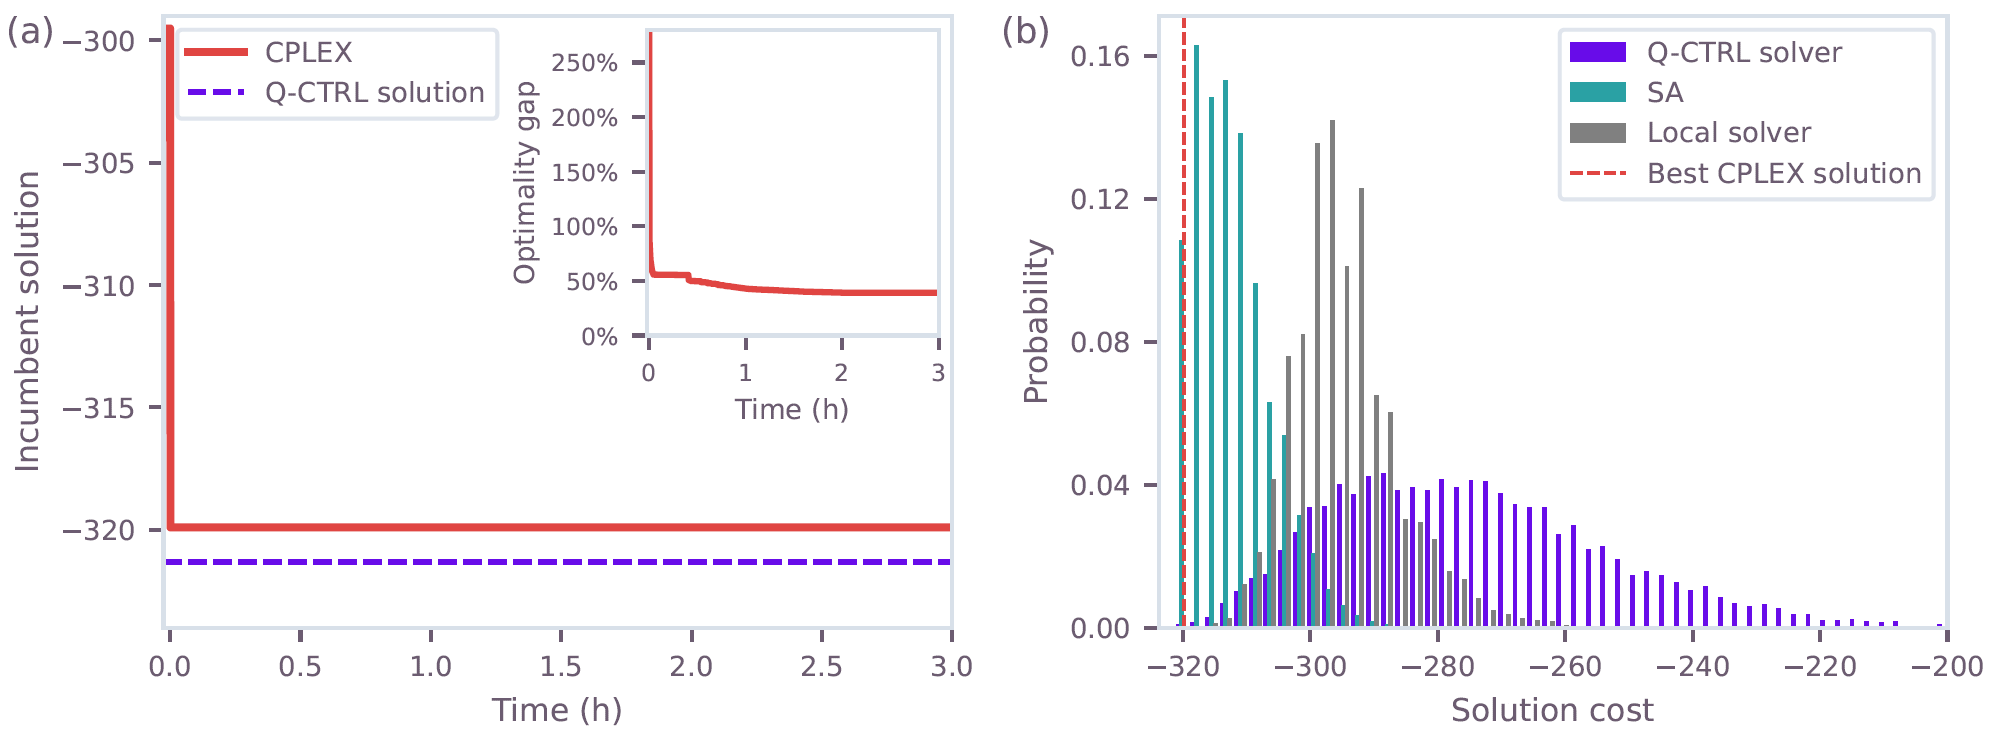
Figure 4: Results for the 123-variable instance (3b7e with ligand, grid spacing 1.9 Å). (a) CPLEX best feasible solution over time (red) vs. Q-CTRL best solution (dashed purple). Inset: optimality gap over time. (b) Cost distributions for Q-CTRL on `ibm_pittsburgh` (purple), simulated annealing (teal), and local solver (gray), with the best CPLEX solution (dashed red). 

### 5.3 Hardware Generation Comparison: Heron r2 vs. r3

A subset of instances was run on both the Heron r2 backend (`ibm_kingston`) and the Heron r3 backend (`ibm_pittsburgh`). Significant performance improvements were observed on the newer hardware, highlighting the direct impact of hardware advances on optimization quality.

<center>
    
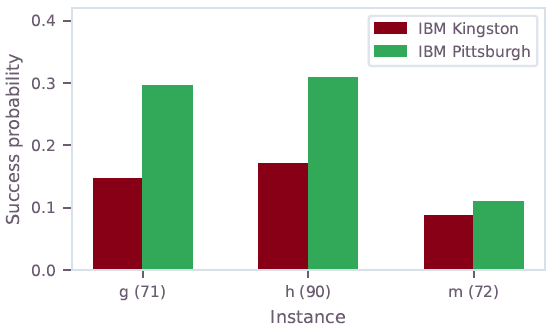

</center>

Figure 5: Success probability comparison between `ibm_kingston` (Heron r2, red) and `ibm_pittsburgh` (Heron r3, green) for selected test instances.

### 5.4 Hydration-Site Prediction Accuracy

The quality of the predicted water (PW) positions is assessed against experimentally determined crystallographic water (CW) positions using four metrics:

- **$C$** (Coverage): fraction of CWs identified by at least one PW within a 3 Å radius
- **$P^*$** (Closest-water precision): average precision score of the single closest PW to each CW
- **$\langle P \rangle$** (Cluster-averaged precision): precision averaged over all PWs in the cluster around each CW
- **$\langle CS \rangle$** (Average cluster size): mean number of PWs associated with each CW

All metrics consistently improve with increasing QUBO instance size. For the quantum-hardware-tractable instances (up to 123 variables), the method recovers approximately 60% of crystal waters. Scaling to larger instances (900–6824 variables, solved classically with SA) demonstrates that coverage reaches $\sim90\%$ and precision continues to increase.

<center>

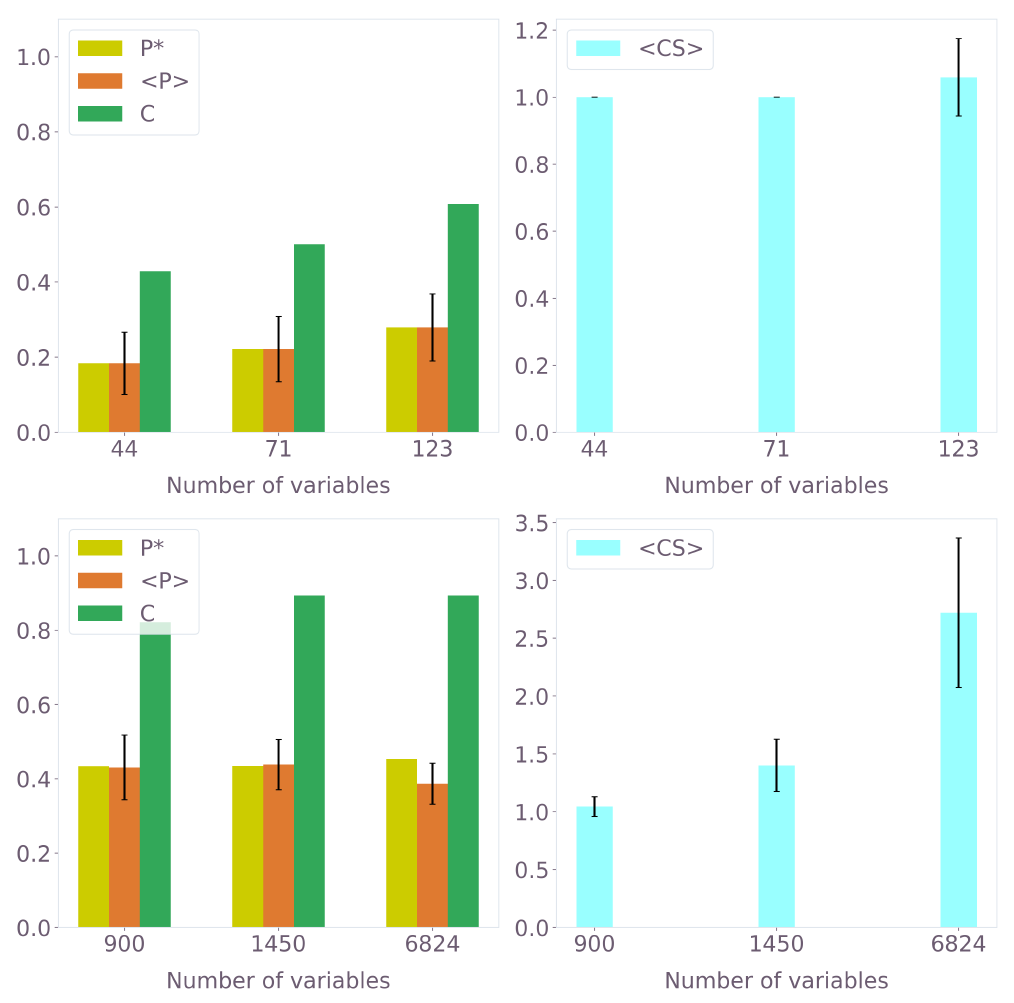

</center>

Figure 6: Hydration-site prediction performance across different QUBO instance sizes for PDB ID 3b7e with ligand. Top: quantum hardware results (Q-CTRL solver). Bottom: classical SA results on larger instances. Left plots show $P^*$, $\langle P \rangle$, and $C$; right plots show $\langle CS \rangle$. 

### 5.5 Comparison with Classical Hydration-Site Prediction Methods

The QUBO-based approach was compared to a selection of established classical methods: Hydraprot (deep learning), Placevent (3D-RISM-based peak extraction), Watgen, and Dowser++. Since the comparison requires QUBO instances larger than current quantum hardware supports, the best-performing QUBO solutions at 900 and 3974 variables were obtained using the classical SA heuristic.

<center>

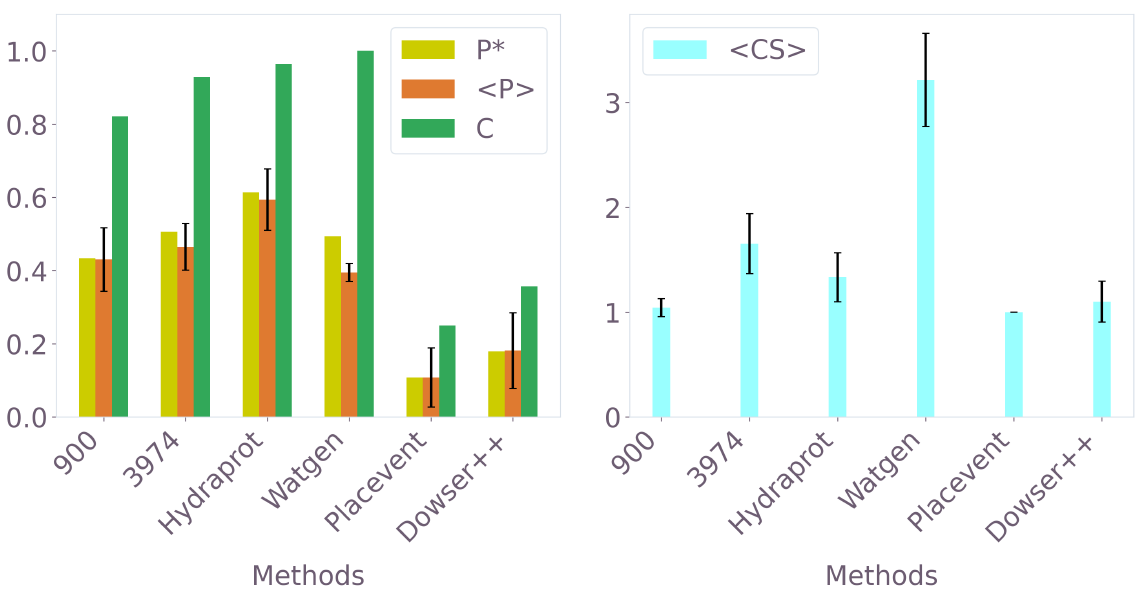

</center>

Figure 7: Comparative performance analysis. The two best-performing QUBO models (900 and 3974 variables) are compared against Hydraprot, Watgen, Placevent, and Dowser++ on the 3b7e test case with ligand.

The QUBO approach and Hydraprot show the best overall performance, with similar precision metrics and better results than the other methods. Placevent, which also uses 3D-RISM input, is outperformed by the QUBO formulation, demonstrating the value of the optimization-based approach over direct peak extraction.

### 5.6 Hydration-Site Visualization

The 3D visualization (left panels) places the predicted water oxygen atoms (red spheres) alongside the reference crystallographic waters targeted for prediction (blue) and all crystal waters in the original PDB file (yellow) within the binding pocket of PDB ID 3b7e. Since 3D molecular views can be difficult to interpret, a principal component analysis (PCA) was applied as a dimensionality reduction step: the combined set of predicted and crystal water coordinates was projected onto the two directions capturing the most spatial variance (PC1, PC2), yielding the 2D scatter plots on the right.

For the 123-variable instance (panel a), the method places 18 predicted waters and recovers roughly $60\%$ of the $28$ crystal water positions, consistent with the metrics reported in Section 5.4. Scaling to 900 variables (panel b) increases the number of predicted waters to $24$ and visibly improves spatial overlap with the crystal water set: more blue circles acquire a nearby red square, and the remaining gaps shrink. This visual progression reinforces the quantitative finding that prediction accuracy improves systematically with QUBO instance size, motivating the push toward larger-scale quantum hardware execution.

<center>

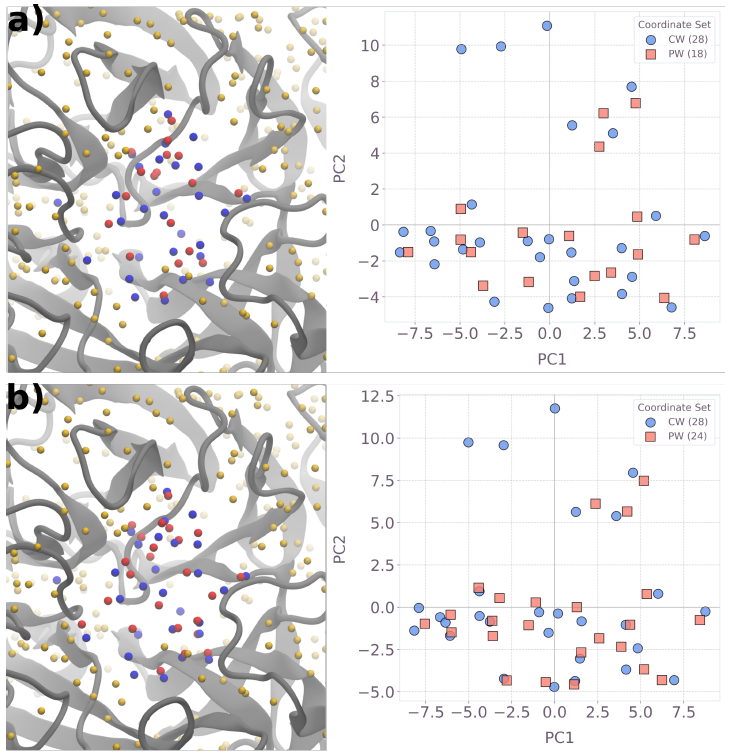

</center>

Figure 8: Visualization of predicted hydration sites for the 123-variable (panel a) and 900-variable (panel b) instances of PDB ID 3b7e. Left: 3D molecular visualization (red spheres = predicted waters, blue = reference crystal waters, yellow = all PDB crystal waters). Right: PCA projection for easier comparison of predicted vs. crystal water positions. 

## 6. Running the QUBO Solver

The following code demonstrates how to solve the hydration-site prediction QUBO using Q-CTRL's Fire Opal optimization solver. 

### 6.1 Setup and Authentication

In [13]:
import os
import pickle
from sympy import Poly, symarray
import fireopal as fo

In [ ]:
# Set credentials.
token = "YOUR_IBM_CLOUD_API_KEY"
instance = "YOUR_IBM_CRN"

credentials = fo.credentials.make_credentials_for_ibm_cloud(
    token=token, instance=instance
)

Q-CTRL authentication successful!


### 6.2 Load QUBO Matrix and Construct Cost Function

The QUBO matrix is pre-computed from the 3D-RISM density of the target protein pocket. Here we load the matrix for the 3b7e structure with ligand (71 variables, instance "g" from Table 2) and construct the corresponding cost polynomial for the solver.

In [32]:
with open("resources/Q_matrix_nparray_3b7eL_71_variables.pkl", "rb") as file:
    qubo_matrix = pickle.load(file)
print(qubo_matrix.shape[0])

71


In [33]:
n_var = len(qubo_matrix)
variables = symarray("n", n_var)
cost = Poly(0, *variables)

for i in range(n_var):
    # linear terms
    cost += qubo_matrix[i, i] * variables[i]
    # quadratic terms
    for j in range(i + 1, n_var):
        cost += 2 * qubo_matrix[i, j] * variables[i] * variables[j]

cost_function = Poly(cost, *variables)

### 6.3 Execute on Quantum Hardware

The cost function is submitted to the Q-CTRL optimization solver targeting an IBM Heron r3 backend. The solver handles the full variational optimization loop including ansatz construction, error-suppressed circuit execution, and classical postprocessing.

In [ ]:
backend_name = "ibm_pittsburgh"

In [44]:
fire_opal_job = fo.solve_qaoa(cost_function, credentials, backend_name=backend_name)

This function performs multiple consecutive runs. Wait time may vary depending on hardware queues.



In [52]:
result = fire_opal_job.result()

### 6.4 Extract and Inspect Results

The solver returns the best solution bitstring and its associated cost. Each bit in the solution corresponds to a spatial grid point: a value of 1 indicates a predicted water molecule at that location.

In [ ]:
print(result["solution_bitstring"])
print(result["solution_bitstring_cost"])

01000000000001000010001000010110000100010000100010010000000000011000000
-226.5011309999111


### 6.5 Visualize Cost Distribution

The following functions evaluate the cost of sampled bitstrings and plot the distribution, highlighting the optimal solution identified by the solver.

In [ ]:
import re
import sympy as sp

_n_pat = re.compile(r"^n_(\d+)$")


def evaluate_poly_cost(poly_or_expr, bitstring, *, n0_is_leftmost=True):
    expr = poly_or_expr.as_expr() if isinstance(poly_or_expr, sp.Poly) else poly_or_expr
    bits = (
        [int(c) for c in bitstring]
        if isinstance(bitstring, str)
        else list(map(int, bitstring))
    )
    if not n0_is_leftmost:
        bits = bits[::-1]
    n_syms = []
    for s in expr.free_symbols:
        m = _n_pat.match(s.name)
        if m:
            n_syms.append((int(m.group(1)), s))
    n_syms.sort(key=lambda t: t[0])
    if not n_syms:
        return float(expr)
    max_i = n_syms[-1][0]
    subs_map = {sym: bits[i] for i, sym in n_syms}
    return float(expr.subs(subs_map))

In [ ]:
import matplotlib.pyplot as plt


def plot_top_bitstrings_cost(
    counts_dict, cost_poly, top_k=50, best_cost=-226.5011309999112, tol=1e-9
):
    top = sorted(counts_dict.items(), key=lambda x: x[1], reverse=True)[:top_k]
    denom = sum(counts_dict.values()) or 1

    rows = sorted(
        [
            (evaluate_poly_cost(cost_poly, b, n0_is_leftmost=False), c / denom, c)
            for b, c in top
        ],
        key=lambda t: (t[0], -t[2]),
    )
    costs, probs = [r[0] for r in rows], [r[1] for r in rows]
    best = {i for i, c in enumerate(costs) if abs(c - best_cost) <= tol}
    plt.figure(figsize=(15, 8))
    bars = plt.bar(
        range(len(costs)),
        probs,
        color=["#680CE9" if i in best else "#B0B0B0" for i in range(len(costs))],
        edgecolor="black",
        linewidth=0.7,
        label="Q-CTRL Optimization Solver",
    )
    line = (
        plt.axvline(
            next(iter(best)),
            color="red",
            linestyle=(0, (4, 4)),
            linewidth=1.5,
            alpha=0.65,
            label="Best CPLEX solution",
            zorder=3,
        )
        if best
        else None
    )

    plt.legend(handles=[h for h in (bars, line) if h], fontsize=14)
    plt.xticks(range(len(costs)), [f"{c:.6g}" for c in costs], rotation=45, fontsize=12)
    plt.yticks(fontsize=12)
    plt.xlabel("Cost", fontsize=18)
    plt.ylabel("Probability", fontsize=18)
    plt.tight_layout()
    plt.show()

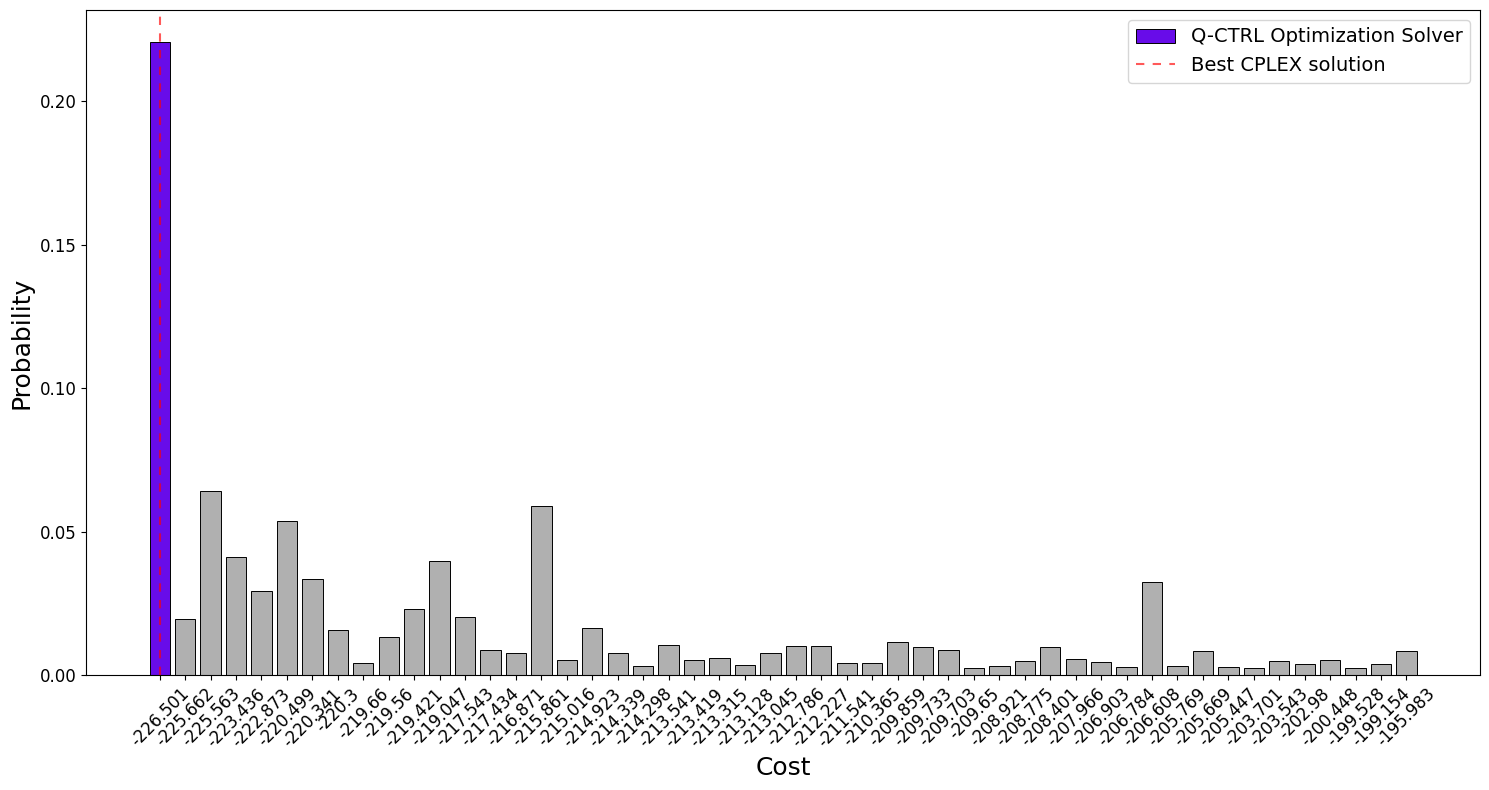

In [ ]:
plot_top_bitstrings_cost(
    result["final_bitstring_distribution"], cost_function, top_k=50
)

## 7. Advantage Forecasting

A resource estimation analysis was performed to project when quantum computing may achieve practical advantage for this application. The two-qubit gate count scales approximately quadratically with the number of QUBO variables (Figure 9). At the target scale of 900 variables, where the QUBO-based method becomes competitive with other hydration prediction approaches, approximately 100,000 two-qubit gates would be required.


<center>

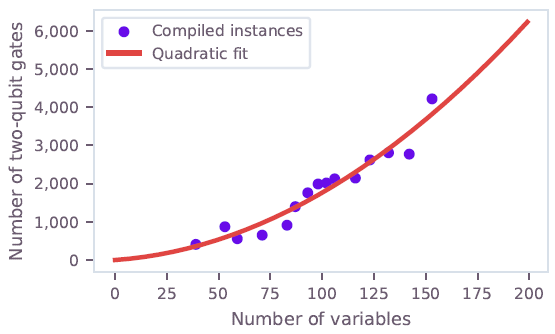

</center>

Figure 9: Two-qubit gate count scaling with problem size for the 3b7e-with-ligand structure. Purple dots show compiled gate counts; red line shows a quadratic fit used for extrapolation.


## 8. Discussion and Conclusion

This work demonstrates that quantum optimization can be practically applied to a recurrent task in computer-aided drug discovery: predicting water molecule positions in protein binding pockets. The QUBO-based method, solved using Q-CTRL's Fire Opal optimization solver on IBM Heron hardware, successfully identifies optimal solutions across all test instances up to 123 qubits. For this problem class, the quantum solver achieves performance overall comparable to simulated annealing across the test set, and at 123 variables both heuristic approaches find lower-cost solutions than the exact classical solver CPLEX within significantly shorter runtimes.

The hydration-site predictions produced by the optimal QUBO solutions match the precision of established classical methods including Hydraprot (deep learning) and Watgen, while outperforming Placevent despite both using 3D-RISM input. Prediction accuracy scales systematically with QUBO instance size, with coverage of crystallographic waters reaching $\sim90\%$ at $1,450$ variables.

The path to quantum advantage is mapped through a detailed resource estimation. The target scale of $\sim900$ variables, where the method becomes competitive with the best classical alternatives, requires on the order of $100,000$ two-qubit gates and $\sim1,000$ qubits. This opens the possibility that quantum optimization could deliver practical value in CADD pipelines in the near term, assisting in the preparation of protein–ligand complexes for molecular dynamics simulations, docking calculations, and ultimately drug lead optimization.